# How to use anis_pta_jax to do anisotropy decompositions given PTA cross-correlations

### There are two sections to this notebook. In the first, we'll simulate cross-correlation data. If you're working with real data, you can skip this section and go to Section II since you'll get cross-correlation data through Defiant.

# Section I: Simulate cross-correlation data

### We need cross-correlations ($\rho$), an amplitude ($S$ or $A^2$), and a covariance matrix ($C$).

#### We can simulate noiseless cross-correlations using the PTA response matrix $R$ and a GWB angular distribution $P$.

In [1]:
import numpy as np, healpy as hp
import matplotlib.pyplot as plt
from enterprise.signals import anis_coefficients as ac
from maps import anis_pta_jax as apj

In [2]:
# This cell gets the response matrix
np.random.seed(1)
psrs_theta = np.random.uniform(0, np.pi, 75)
psrs_phi = np.random.uniform(0, 2*np.pi, 75)

gwtheta, gwphi = hp.pix2ang(nside=8, ipix=np.arange(12*8**2))

pair_idx = np.array(np.triu_indices(len(psrs_phi),1)).T
pair_idx_a, pair_idx_b = pair_idx[:,0], pair_idx[:,1]

R, _, _ = apj.signalResponse_fast(psrs_theta, psrs_phi, gwtheta, gwphi, pair_idx_a, pair_idx_b)

#### Next we can make a simulated GWB

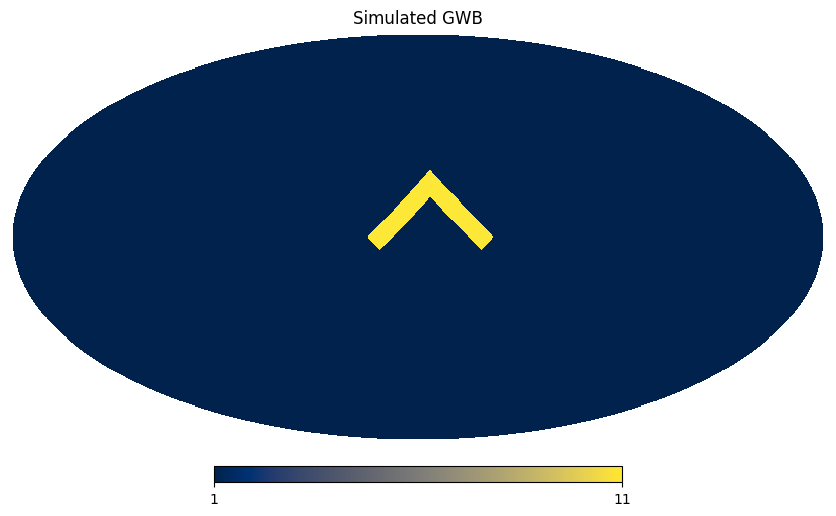

In [3]:
P = np.ones(12*8**2)
indices = [255,288,287,318,320,350,353,381,385]
P[indices] += 10
hp.mollview(P, rot=180, cmap='cividis', title='Simulated GWB');

#### Get simulated cross-correlations by multiplying $R$ and $P$. We can also choose uncertainties for our covariance matrix.

In [4]:
rho = R @ P
sigma = np.ones_like(rho)/10
C = np.diag(sigma**2)
N_inv = np.linalg.inv(C)

#### In the previous cell, we simulated a diagonal covariance matrix. The process in Section II works the same whether you are using the pair covariant covariance matrix or neglecting pair covariance. Next, we'll get a simulated amplitude by fitting the HD curve to $\rho$.

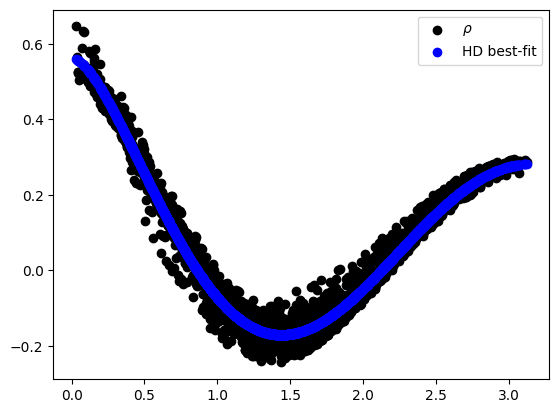

In [5]:
xi = apj.get_xi(psrs_theta, psrs_phi, pair_idx)
HD = apj.get_pure_HD(xi)
A2 = (HD.T @ N_inv @ rho) / (HD.T @ N_inv @ HD)
plt.scatter(xi, rho, color='black', label=r'$\rho$')
plt.scatter(xi, A2*HD, color='blue', label='HD best-fit')
plt.legend();

# Section II: Use anis_pta_jax for anisotropy decompositions

### The main function users should use in anis_pta_jax is correlations2anisotropy.

#### This function requires 6 arguments:

##### 1) psrs_theta : the theta positions of the pulsars
##### 2) psrs_phi : the phi positions of the pulsars
##### 3) rho : the cross-correlations from Defiant (or simulated)
##### 4) S : the amplitude from Defiant (or simulated). This can also be referred to as A2.
##### 5) C : the covariance matrix from Defiant (or simulated). This can be pair-covaraint or not.
##### 6) basis : a string of either 'sqrt', 'radiometer', 'spherical', or 'pixel' specifying which basis to use

#### It outputs a tuple of two elements. A basis_decomposition dictionary and an anisotropic SNR squared float.

#### The pixel basis uses the LBFGS algorithm, which seems to be a lot slower and less performant than Levenberg-Marquardt but is more stable due to the nature of the pixel basis. 

#### I recommend setting maxiter to something like 500-5000 when using this algorithm with the pixel basis. For the LM algorithm, which is used in the spherical harmonic and square-root spherical harmonic bases, you can set maxiter much lower (the default is 30, which is usually fine).

In [6]:
basis_decomposition, snr_squared = apj.correlations2anisotropy(psrs_theta, psrs_phi, rho, A2, C, 'pixel', maxiter=5000)
snr_squared

Array(246.28532284, dtype=float64)

#### Take the square root of snr_squared to get the anistropic SNR.

In [7]:
snr = np.sqrt(snr_squared)
snr

15.693480265525755

#### Next we'll look at the form of the decomposition for each basis and see some post-processing examples.

#### 1. Pixel basis

##### basis_decomposition contains three keys: 'A2' gives the amplitude of best fit for the overlap reduction function (ORF).
##### 'pixel_map' contains the recovered map. It needs to be inverted using maps.utils.invert_omega if you use real cross-correlations from Defiant.
##### 'state' contains the state of the final step in the JAXopt solver, which can be useful for understanding how the solve went.

#### Note that all the maps in this notebook should be multiplied by basis_decomposition['A2'], but I skipped it for no reason. You should include it though.

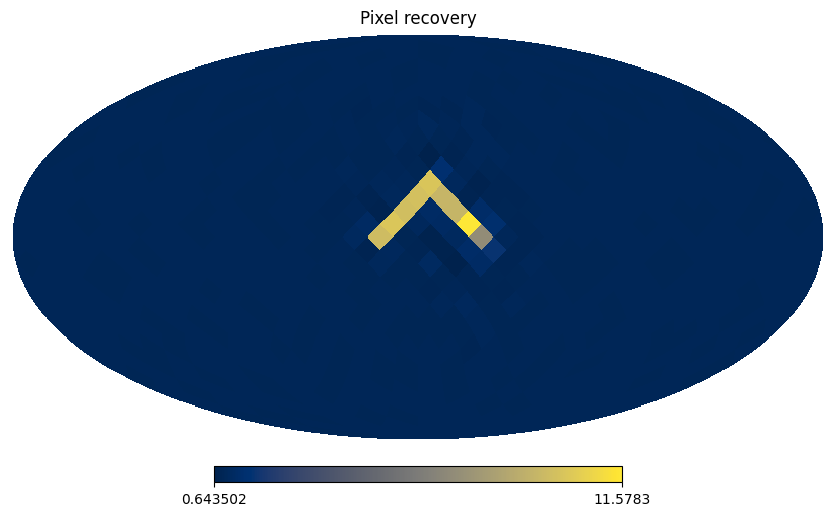

In [8]:
hp.mollview(basis_decomposition['pixel_map'], rot=180, cmap='cividis', title='Pixel recovery');

### Next is the radiometer basis
#### This basis is analytical, so maxiter (and tol (= tolerance for stopping early)) are ignored.
#### The decomposition contains 'A2' which is the best fit amplitude, 'pixel_map' which is the radiometer map, and 'pixel_map_err' which is the uncertainties in the pixels.

In [9]:
basis_decomposition, snr_squared = apj.correlations2anisotropy(psrs_theta, psrs_phi, rho, A2, C, 'radiometer', nside=16)
snr = np.sqrt(snr_squared)
snr

/tmp/ipykernel_811993/192278773.py:2: RuntimeWarning: invalid value encountered in sqrt
  snr = np.sqrt(snr_squared)


nan

#### A nan snr here means HD (isotropy) is preferred to the radiometer decomposition. This is not too uncommon for the radiometer basis. The recovery is not very good, but you can increase the injection strength to get a better result.

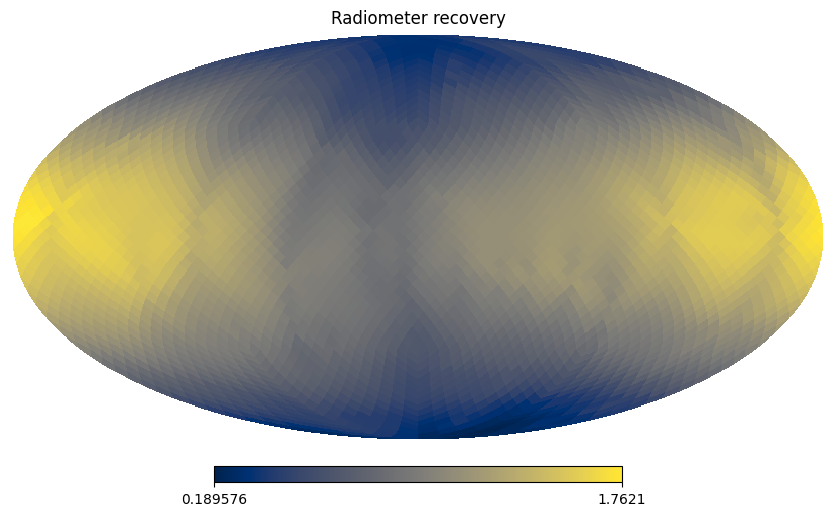

In [10]:
hp.mollview(basis_decomposition['pixel_map'], rot=180, cmap='cividis', title='Radiometer recovery');

### Next is the spherical harmonics basis.
#### The basis_decomposition here contains 'A2' which is the best-fit amplitude, 'clm' which contains the clms, and 'state' which is the final JAXopt state.

In [11]:
basis_decomposition, snr_squared = apj.correlations2anisotropy(psrs_theta, psrs_phi, rho, A2, C, 'spherical')
snr = np.sqrt(snr_squared)
snr

15.521728683211348

/home/tmoursy/miniforge3/envs/pulsar2/lib/python3.12/site-packages/enterprise/signals/anis_coefficients.py:194: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  h = hp.alm2map(alm, nside, maxl, verbose=False)


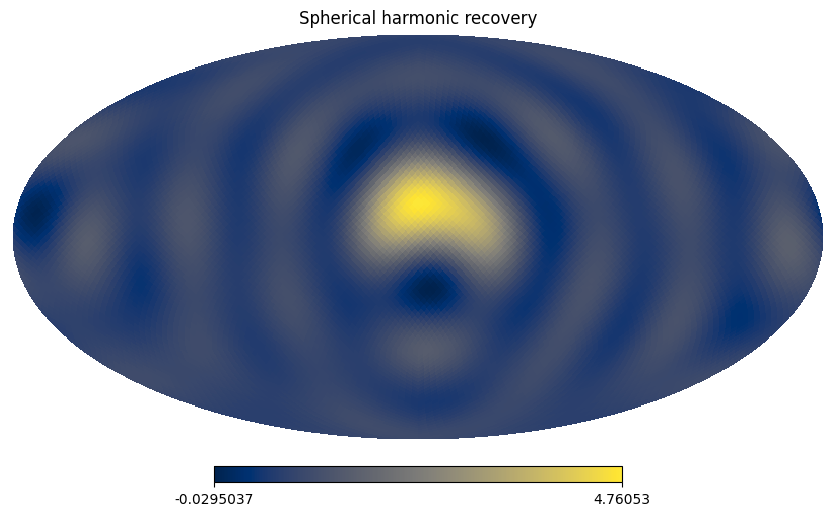

In [12]:
hp.mollview(ac.mapFromClm_fast(basis_decomposition['clm'], nside=32), rot=180, cmap='cividis', title='Spherical harmonic recovery');

### The final basis is the square-root spherical harmonics.
#### The outputs are the same as the spherical harmonic basis above.

##### Note that this basis requires computing some Clebsch Gordan coefficients, which takes minutes for l_max ~ 20. 
##### This module of MAPS saves the coefficients the first time they are computed, so you will only have to wait the very first time you use a new l_max.

In [13]:
basis_decomposition, snr_squared = apj.correlations2anisotropy(psrs_theta, psrs_phi, rho, A2, C, 'sqrt', l_max = 14)
snr = np.sqrt(snr_squared)
snr

No precomputed CG coefficients found for this l_max. Computing them from scratch...
Done.
Saving computed CG coefficients to MAPS directory for next time.
Done saving.


15.366471089729396

/home/tmoursy/miniforge3/envs/pulsar2/lib/python3.12/site-packages/enterprise/signals/anis_coefficients.py:194: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  h = hp.alm2map(alm, nside, maxl, verbose=False)


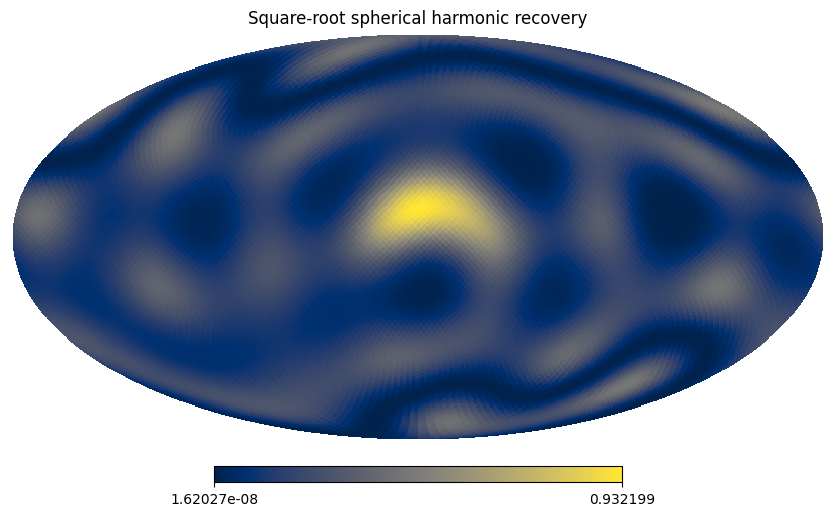

In [14]:
hp.mollview(ac.mapFromClm_fast(basis_decomposition['clm'], nside=32), rot=180, cmap='cividis', title='Square-root spherical harmonic recovery');

#### Here's some speed comparisons (on CPU). The pixel basis can be much faster (~1-2 seconds) if using Levenberg-Marquardt, but I went for stability at the cost of speed in this module of MAPS by using LBFGS instead. The two spherical harmonic bases really take about 1s each, but it shows 4-5 seconds here due to some caching/compilation that occur the first time they are called for each new l_max.
#### The last line of this cell takes a long time (~10 minutes).

In [15]:
from jax import block_until_ready as block
print('Radiometer:')
%timeit block(apj.correlations2anisotropy(psrs_theta, psrs_phi, rho, A2, C, 'radiometer'))
print('Spherical:')
%timeit block(apj.correlations2anisotropy(psrs_theta, psrs_phi, rho, A2, C, 'spherical'))
print('Square-root spherical:')
%timeit block(apj.correlations2anisotropy(psrs_theta, psrs_phi, rho, A2, C, 'sqrt'))
print('Pixel:')
%timeit block(apj.correlations2anisotropy(psrs_theta, psrs_phi, rho, A2, C, 'pixel', maxiter=5000))

Radiometer:
1.28 s ± 600 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Spherical:
The slowest run took 7.70 times longer than the fastest. This could mean that an intermediate result is being cached.
4.95 s ± 2.38 s per loop (mean ± std. dev. of 7 runs, 1 loop each)
Square-root spherical:
The slowest run took 7.23 times longer than the fastest. This could mean that an intermediate result is being cached.
4.48 s ± 2.88 s per loop (mean ± std. dev. of 7 runs, 1 loop each)
Pixel:
1min 39s ± 13.7 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


### That's all there is to it.

### Some final notes:
##### 1) apj.correlations2anisotropy supports automatic batching through internal usage of JAX's vmap transformation. This means you can pass a whole spectrum of PFOS rhok, Sk, and Ck, and perform batched anisotropy recoveries. The same is true for noise-marginalization, and you can do both at the same time (i.e., a 3d array of rhok).
##### 2) apj.correlations2anisotropy also supports automatic GPU accleration through usage of JAX. To make use of this, install JAX with CUDA support (see JAX's installation instruction, which typically is as simple as pip install jax[cuda13]).
##### 3) Using apj.correlations2anisotropy is not the most efficient way to do anisotropy searches, so if you are doing very large amounts of analyses, it may be worth the time to make a tailored, highly-optimized script for your specific analysis. As one example, if you are using multiple bases, you can use JAX's vmap transformation over the bases as well, which apj.correlations2anisotropy does not support.